# Results Comparison

This notebook will evaluate and compare the performance of all of the models using Tensorboard and code-based metrics.


## Import Dependencies


In [1]:
import os
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator
import pickle

In [2]:
%matplotlib inline

## run tensorboard logging


In [3]:
# %load_ext tensorboard
# %tensorboard --logdir TensorBoard/runs --port 6006

## Read Events Files


### paths and defns


In [4]:
RUNS_DIR: Path = Path('TensorBoard/runs')


model_groups = {
    'YOLO': {
        'yolov8-amy': [],
        'yolov8-Joachim': [],
        'yolov11': [],
        'yolov12': []
    },
    'COCO': {
        'efficientDet': [],
        'faster-rcnn': [],
        'rf-detr': [],
        'retina-net': []
    },
    'SIGN_ATTR': {
        'sign-condition': [],
        'sign-shape': [],
        'viewing-angle': [],
        'mounting-type': []
    }
}

In [5]:
# fn to load a single file
def extract_scalars_from_event(event_path, model_name, category) -> pd.DataFrame:
    """
    Read a single event file and returns a DataFrame of all scalar metrics.
    """
    # Load the event file with full size guidance
    ea = EventAccumulator(str(event_path), size_guidance={'scalars': 0})
    ea.Reload()
    
    scalar_tags = ea.Tags()['scalars']
    if not scalar_tags:
        return pd.DataFrame() # Return empty if no scalars found

    dfs = []
    
    # Extract data for every metric (tag) found in the file
    for tag in scalar_tags:
        events = ea.Scalars(tag)
        temp_df = pd.DataFrame(events)
        
        # Keep relevant columns and rename
        temp_df = temp_df[['step', 'value']]
        temp_df['metric'] = tag
        dfs.append(temp_df)
        
    # Combine all metrics for this model
    if dfs:
        full_df = pd.concat(dfs, ignore_index=True)
        full_df['model'] = model_name
        full_df['category'] = category
        return full_df
    return pd.DataFrame()

In [6]:
# seqrch for logs


for cat, models_list in model_groups.items():
    for model in models_list:
        
        # get model dir
        model_dir = RUNS_DIR / model
        
        # find event files
        event_files = list(model_dir.glob('events.out.tfevents.*'))
        
        for event in event_files:
            
            # # get the latest event file
            # latest_event_file = max(event_files, key=os.path.getmtime)
            
            # try save the results
            try:
                df = extract_scalars_from_event(event, model, cat)
                if not df.empty:
                    model_groups[cat][model].append(df)
                    # break  # exit while loop if successful
                else:
                    raise ValueError(f'No scalar data found in event file for model: {model}')
            except Exception as e:
                print(f'Error processing model: {model}. Error: {e}')
                # catch error, remove current file and try next latest
                # event_files.remove(event)
        print(model_groups[cat][model])

Error processing model: yolov8-amy. Error: No scalar data found in event file for model: yolov8-amy
Error processing model: yolov8-amy. Error: No scalar data found in event file for model: yolov8-amy
[      step    value          metric       model category
0        1  1.04562  train/box_loss  yolov8-amy     YOLO
1        2  0.99562  train/box_loss  yolov8-amy     YOLO
2        3  1.02341  train/box_loss  yolov8-amy     YOLO
3        4  0.95569  train/box_loss  yolov8-amy     YOLO
4        5  1.03757  train/box_loss  yolov8-amy     YOLO
...    ...      ...             ...         ...      ...
1381    73  0.91195    val/dfl_loss  yolov8-amy     YOLO
1382    74  0.91846    val/dfl_loss  yolov8-amy     YOLO
1383    75  0.91730    val/dfl_loss  yolov8-amy     YOLO
1384    76  0.91924    val/dfl_loss  yolov8-amy     YOLO
1385    77  0.91589    val/dfl_loss  yolov8-amy     YOLO

[1386 rows x 5 columns],      step    value          metric       model category
0      78  0.68009  train/box_los

In [7]:
# save the compiled data
with open('compiled_model_data.pkl', 'wb') as f:
    pickle.dump(model_groups, f)

# print summary & collect dataframes into a list
dataframes_list = []
for model in model_groups.values():
    for name, df_list in model.items():
        dataframes_list.extend(df_list)
        for df in df_list:
            print(f'Model: {name}, DataFrame shape: {df.shape}')

Model: yolov8-amy, DataFrame shape: (1386, 5)
Model: yolov8-amy, DataFrame shape: (418, 5)
Model: yolov8-Joachim, DataFrame shape: (1400, 5)
Model: yolov12, DataFrame shape: (1804, 5)
Model: efficientDet, DataFrame shape: (60, 5)
Model: faster-rcnn, DataFrame shape: (24475, 5)
Model: rf-detr, DataFrame shape: (40, 5)
Model: rf-detr, DataFrame shape: (416, 5)
Model: sign-condition, DataFrame shape: (832, 5)
Model: sign-shape, DataFrame shape: (688, 5)
Model: viewing-angle, DataFrame shape: (570, 5)
Model: viewing-angle, DataFrame shape: (570, 5)
Model: viewing-angle, DataFrame shape: (570, 5)
Model: viewing-angle, DataFrame shape: (570, 5)
Model: viewing-angle, DataFrame shape: (570, 5)


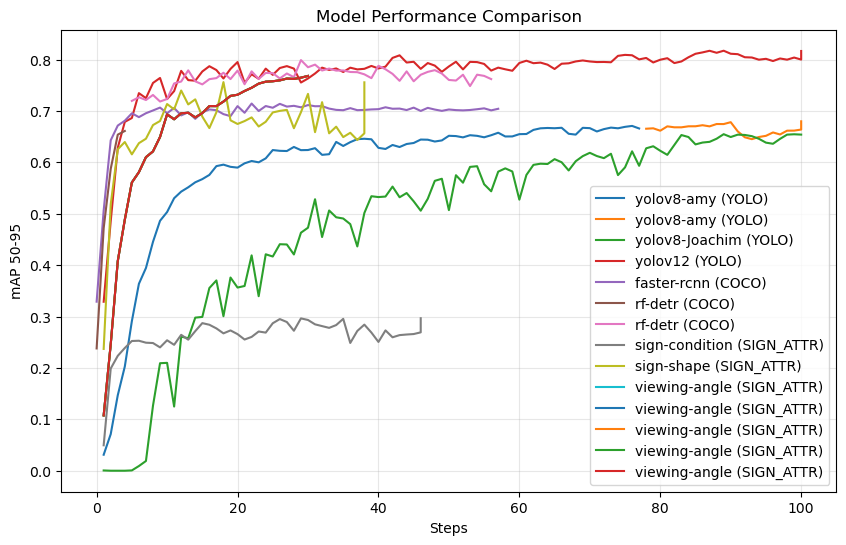

Total DataFrames processed: 15
Missing DataFrames: 0
Total mAP50-95 headers found: 14
Unique mAP50-95 headers found: {'metrics/mAP50(B)', 'metrics/mAP50_B_', 'metrics_mAP50B', 'Metrics/Base/AP50'}


In [8]:
plt.figure(figsize=(10, 6))


# useful stats
stats_dict = {
    'missing_dfs': 0,
    'total_dfs': 0,
    'mAP50-95_headers': set(),
    'map50-95_header_count': 0
}

for df in dataframes_list:
    stats_dict['total_dfs'] += 1
    if df.empty: # because not everyone pushed yet
        stats_dict['missing_dfs'] += 1
        continue

    headers = df['metric'].unique()
    for header in headers:
        if 'AP' in header and '50' in header and 'EMA' not in header and '9' not in header:  # avoid EMA metrics
            stats_dict['mAP50-95_headers'].add(header)
            stats_dict['map50-95_header_count'] += 1
            
            # for the plot
            subset = df[df['metric'] == header]

            # Plot once per model/metric
            plt.plot(
                subset['step'],
                subset['value'],
                label=f"{df['model'].iloc[0]} ({df['category'].iloc[0]})"
            )

plt.xlabel('Steps')
plt.ylabel('mAP 50-95')
plt.title('Model Performance Comparison')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Total DataFrames processed: {stats_dict['total_dfs']}")
print(f"Missing DataFrames: {stats_dict['missing_dfs']}")
print(f"Total mAP50-95 headers found: {stats_dict['map50-95_header_count']}")
print(f"Unique mAP50-95 headers found: {stats_dict['mAP50-95_headers']}")

the results are a bit broken, lets try fix them

2 main issues: 
- overlapping results for the same plot -> how do we choose which one to keep
- one plot cut up into pieces -> can we join them

In [9]:
# we can use num dfs > 1 to detect issues
for model in model_groups.values():
    for name, df_list in model.items():
        if len(df_list) > 1:
            print(f'model: {name}, df count: {len(df_list)}')

            # check if condition 1 or 2
            epochs_sets = [set(df['step'].unique()) for df in df_list]

            # condition 2: check if dfs have different epochs
            all_epochs = set().union(*epochs_sets)
            if len(all_epochs) == sum(len(epochs) for epochs in epochs_sets):
                print(
                    f'  Condition 2 met: Different epochs among DataFrames for model: {name}')
                
                # concatenate the dfs that share no epochs
                combined_df = pd.concat(df_list, ignore_index=True)
                model[name] = [combined_df]
                

            # condition 1: check if all dfs have overlapping epochs
            common_epochs = set.intersection(*epochs_sets)
            if common_epochs:
                print(
                    f'  Condition 1 met: Overlapping epochs among DataFrames for model: {name}')

                # get the best df based on the highest final mAP50-95
                best_df = None
                best_map = -np.inf
                for df in df_list:
                    subset = df[df['metric'].str.contains('AP') & df['metric'].str.contains(
                        '50') & df['metric'].str.contains('9')]
                    final_map = subset[subset['step'] ==
                                       subset['step'].max()]['value'].values[0]
                    if final_map > best_map:
                        best_map = final_map
                        best_df = df
                print(
                    f'  Best DataFrame for model {name} has final mAP50-95: {best_map}')
                model[name] = [best_df]

model: yolov8-amy, df count: 2
  Condition 2 met: Different epochs among DataFrames for model: yolov8-amy
model: rf-detr, df count: 2
  Condition 2 met: Different epochs among DataFrames for model: rf-detr
model: viewing-angle, df count: 5
  Condition 1 met: Overlapping epochs among DataFrames for model: viewing-angle
  Best DataFrame for model viewing-angle has final mAP50-95: 0.6085600256919861


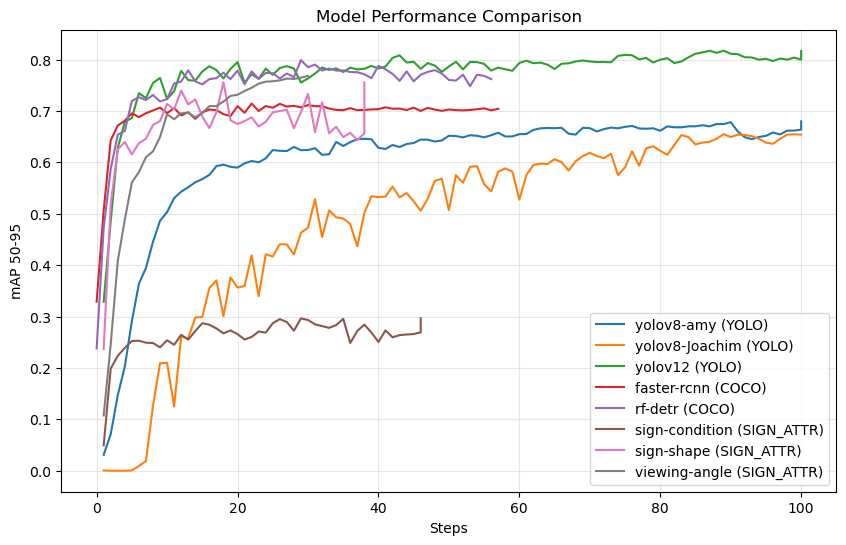

In [10]:
# re-plot using 'fixed' dfs
plt.figure(figsize=(10, 6))


# useful stats
stats_dict = {
    'missing_dfs': 0,
    'total_dfs': 0,
    'mAP50-95_headers': set(),
    'map50-95_header_count': 0
}

for model in model_groups.values():
    for name, df_list in model.items():
        if not df_list:
            continue
        df = df_list[0]  # only one df now
        stats_dict['total_dfs'] += 1
        if df.empty:  # because not everyone pushed yet
            stats_dict['missing_dfs'] += 1
            continue

        headers = df['metric'].unique()
        for header in headers:
            if 'AP' in header and '50' in header and 'EMA' not in header and '9' not in header: # avoid EMA metrics
                stats_dict['mAP50-95_headers'].add(header)
                stats_dict['map50-95_header_count'] += 1

                # for the plot
                subset = df[df['metric'] == header]

                # Plot once per model/metric
                plt.plot(
                    subset['step'],
                    subset['value'],
                    label=f"{df['model'].iloc[0]} ({df['category'].iloc[0]})"
                )

plt.xlabel('Steps')
plt.ylabel('mAP 50-95')
plt.title('Model Performance Comparison')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### comparing apples with apples

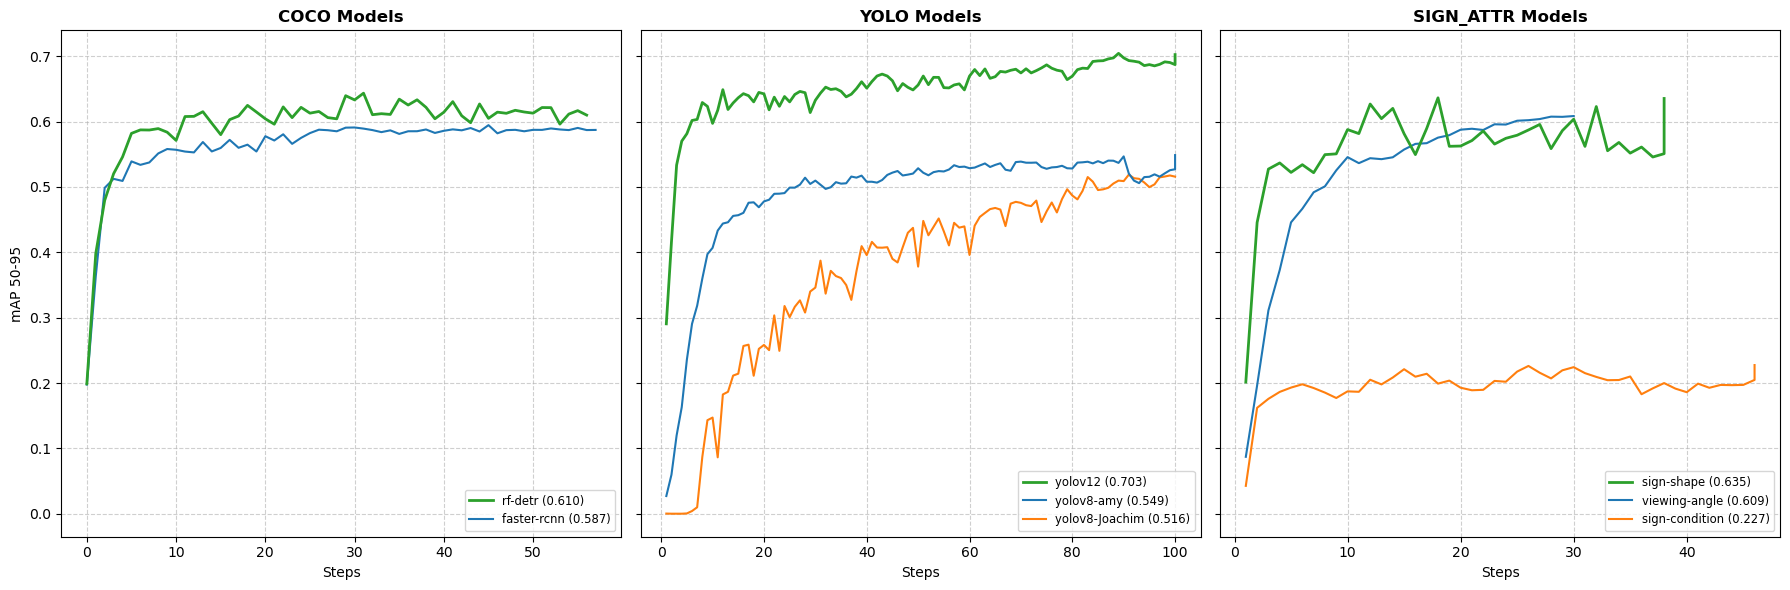

In [11]:
import matplotlib.pyplot as plt

# Define your color priority: Green (1st), Blue (2nd), Orange (3rd), Gray (4th+)
# We add extra grays at the end to handle cases with many models
color_palette = ['#2ca02c', '#1f77b4',
                 '#ff7f0e', '#7f7f7f', '#bcbd22', '#17becf']

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

category_map = {'COCO': 0, 'YOLO': 1, 'SIGN_ATTR': 2}

for model_name, model_content in model_groups.items():
    ax_idx = category_map.get(model_name)
    if ax_idx is None:
        continue
    ax = axes[ax_idx] # type: ignore

    # --- NEW: RANKING LOGIC ---
    performance_list = []

    for name, df_list in model_content.items():
        if not df_list or df_list[0].empty:
            continue
        df = df_list[0]

        # Identify metric
        headers = [h for h in df['metric'].unique(
        ) if 'AP' in h and '50' in h and '9' in h and 'EMA' not in h]
        if not headers:
            continue

        header = headers[0]
        subset = df[df['metric'] == header]

        # Store the last known value to sort by performance
        last_value = subset['value'].iloc[-1]
        performance_list.append({
            'label': df['model'].iloc[0],
            'subset': subset,
            'last_val': last_value
        })

    # Sort models by performance (descending)
    performance_list.sort(key=lambda x: x['last_val'], reverse=True)

    # Plot using the sorted order to assign colors
    for i, item in enumerate(performance_list):
        # Pick color from palette; if we run out, default to gray
        line_color = color_palette[i] if i < len(color_palette) else '#7f7f7f'

        ax.plot(
            item['subset']['step'],
            item['subset']['value'],
            label=f"{item['label']} ({item['last_val']:.3f})",
            color=line_color,
            linewidth=2 if i == 0 else 1.5,  # Optional: Make the winner slightly bolder
            zorder=10 - i                  # Ensure the best model stays on top visually
        )

# Final Touches (Titles, Grid, Labels)
titles = ['COCO Models', 'YOLO Models', 'SIGN_ATTR Models']
for i, ax in enumerate(axes): # type: ignore
    ax.set_title(titles[i], fontweight='bold')
    ax.set_xlabel('Steps')
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend(fontsize='small', loc='lower right')

axes[0].set_ylabel('mAP 50-95') # type: ignore

plt.tight_layout()
plt.show()